<a href="https://colab.research.google.com/github/GigaGoriashvili/image-captioning/blob/main/inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2: Inference and Demonstration

## Setup and Imports
We import the necessary libraries to load the model and process images.

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Mounts Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Loading Artifacts
We load the trained neural network and the tokenizer.

In [ ]:
# CONFIGURATION
BASE_DIR = '/content/drive/MyDrive/DL_Project'
WORKING_DIR = os.path.join(BASE_DIR, 'working')

# Loads Tokenizer
print("Loading Tokenizer...")
with open(os.path.join(WORKING_DIR, 'tokenizer.pkl'), 'rb') as f:
    tokenizer = pickle.load(f)
vocab_size = len(tokenizer.word_index) + 1
print(f"Vocab Size: {vocab_size}")

# Re-Defining the Architecture
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.models import Model

max_length = 35

def define_model(vocab_size, max_length):
    # Feature Extractor (Image)
    inputs1 = Input(shape=(4096,))
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(256, activation='relu')(fe1)

    # Sequence Model (Text)
    inputs2 = Input(shape=(max_length,))
    # mask_zero=True is what caused the loading error previously
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.5)(se1)
    se3 = LSTM(256)(se2)

    # Decoder
    decoder1 = add([fe2, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    return model

# Instantiates and Loads Weights
print("Reconstructing model...")
model = define_model(vocab_size, max_length)

print("Loading weights...")
try:
    model.load_weights(os.path.join(WORKING_DIR, 'final_caption_model.h5'))
    print("Success! Model weights loaded.")
except Exception as e:
    print(f"Error loading weights: {e}")
    print("Make sure the vocab_size matches exactly what was used in training.")

print(f"Model expects max sequence length: {max_length}")

Loading Tokenizer...
Vocab Size: 8353
Reconstructing model...
Loading weights...
Success! Model weights loaded.
Model expects max sequence length: 35


## Preparing the Feature Extractor
To caption a new image, we first need to extract its visual features using VGG16, exactly as we did in the training phase.

In [ ]:
vgg_model = VGG16()
# Removes the classification layer (outputting 4096 features)
feature_extractor = Model(inputs=vgg_model.inputs, outputs=vgg_model.layers[-2].output)
print("VGG16 Feature Extractor initialized.")

def extract_features(image_path):
    """
    Loads an image, resizes it, and extracts features using VGG16.
    """
    image = load_img(image_path, target_size=(224, 224))
    image = img_to_array(image)
    # Reshaping for model (1, 224, 224, 3)
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    image = preprocess_input(image)
    feature = feature_extractor.predict(image, verbose=0)

    return feature

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
VGG16 Feature Extractor initialized.


## The Generation Function

In [ ]:
def idx_to_word(integer, tokenizer):
    """
    Helper to map an integer back to a word.
    """
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def generate_caption(image_path, model, tokenizer, max_length):
    """
    Takes an image path and generates a caption using the trained model.
    """
    photo_feature = extract_features(image_path)

    in_text = 'startseq'

    # Loop to generate words
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')

        # Predicts next word
        yhat = model.predict([photo_feature, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = idx_to_word(yhat, tokenizer)

        if word is None:
            break

        in_text += ' ' + word

        # Stops if end token is generated
        if word == 'endseq':
            break

    final_caption = in_text.replace('startseq', '').replace('endseq', '').strip()
    return final_caption

## Demonstration (Unseen Images)
We will download a few images from the internet to test the model.

Test Case 1: Dog


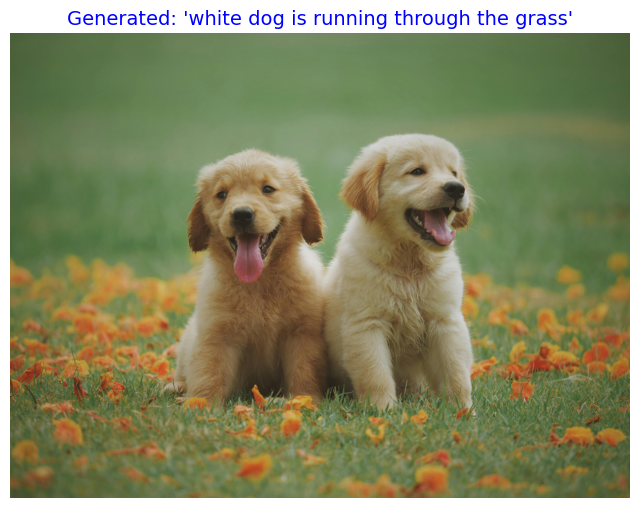

Test Case 2: Sport


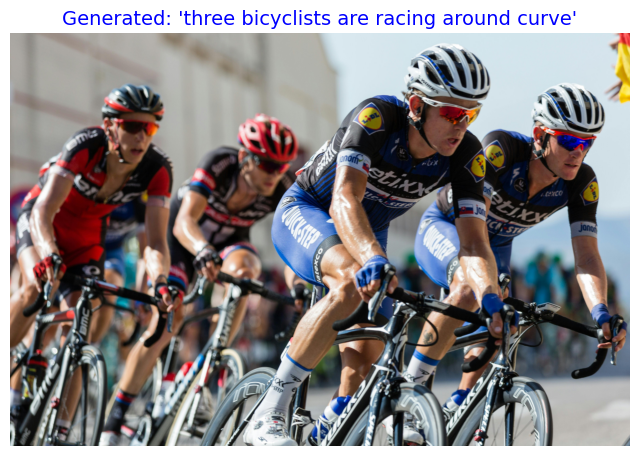

Test Case 3: Beach


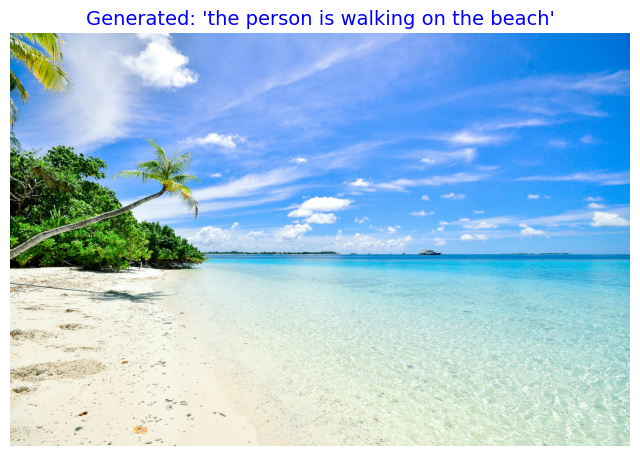

In [ ]:
def demonstrate_model(image_url):
    try:
        # Downloads image
        response = requests.get(image_url)
        img = Image.open(BytesIO(response.content))

        temp_path = 'temp_test_image.jpg'
        img.save(temp_path)

        caption = generate_caption(temp_path, model, tokenizer, max_length)

        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Generated: '{caption}'", fontsize=14, color='blue')
        plt.show()

    except Exception as e:
        print(f"Error processing image: {e}")

# TEST CASES

# 1. A Dog (Standard case)
print("Test Case 1: Dog")
demonstrate_model('https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg')

# 2. A Sport/Action (Motion case)
print("Test Case 2: Sport")
demonstrate_model('https://images.pexels.com/photos/248547/pexels-photo-248547.jpeg')

# 3. A Beach/Scenery (Scene case)
print("Test Case 3: Beach")
demonstrate_model('https://images.pexels.com/photos/457882/pexels-photo-457882.jpeg')

## Analysis of Failure Cases
In this section, we analyze a case where the model might fail.

Common failures include: Repetition ("dog dog dog"), hallucination (seeing objects not there), or generic captions ("a person is standing").

Test Case 4: Complex/Ambiguous Image (Potential Failure)


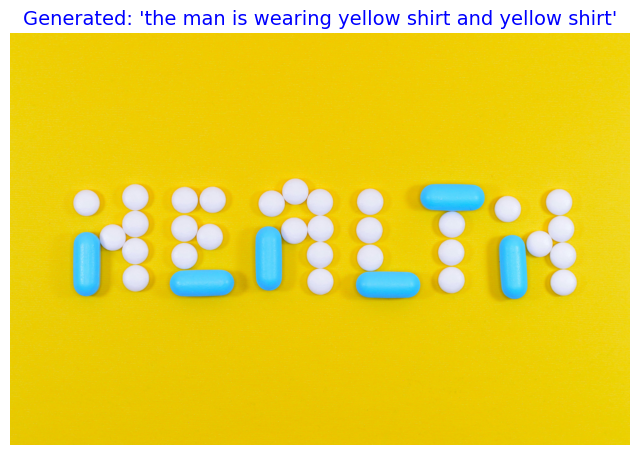

In [ ]:
print("Test Case 4: Complex/Ambiguous Image (Potential Failure)")
# Using an image that might be confusing (e.g., a close up of food or abstract object)
demonstrate_model('https://images.pexels.com/photos/806427/pexels-photo-806427.jpeg')

## More about Fails and Reasons
### If the model fails (or gaves a generic caption), here are possible reasons:

1. **Dataset Bias:** The Flickr8k dataset is heavy on dogs, children, and outdoor sports. It often struggles with indoor objects, food, or abstract concepts because it hasn't seen enough of them.
2. **Greedy Search:** We used simple Argmax (picking the #1 word). This can sometimes lead to repetitive loops. A more advanced method called 'Beam Search' often yields better results but is slower.
3. **Padding:** If the caption is grammatically weird, the model might be struggling to understand the 'post' padding if the training epochs were low.